# Comparing Glider Observations with Satellite Data
### Authors: Madison Richardson, Cara Wilson, & Dale Robinson

> History | Updated Sept 2026

This tutorial demonstrates how to compare in situ ocean glider observations with satellite-derived oceanographic measurements using Python.

Glider observations from CalCOFI Line 90 are retrieved from the Scripps Spray Glider ERDDAP server. Corresponding satellite observations are then retrieved from NOAA CoastWatch ERDDAP servers and matched to the glider observations in space and time.

The comparison includes:

- Chlorophyll-a
- Sea surface temperature (SST)
- Sea surface salinity (SSS)

The workflow demonstrates how to access remote ERDDAP datasets, subset Xarray datasets, extract satellite observations around glider locations, and visualize the resulting comparisons.

## Load packages

In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from erddapy import ERDDAP

## Define a Function for Opening ERDDAP Datasets

The satellite datasets used in this tutorial are available through ERDDAP's `griddap` service. The following helper function constructs a remote ERDDAP URL from a dataset ID and opens the dataset directly with Xarray.

Using a function avoids repeating the same URL-building steps for each satellite dataset.

In [2]:
def xr_open_ds(
    e_id, e_source="https://coastwatch.pfeg.noaa.gov/wcn/erddap", dap="griddap"
):
    """
    Open a remote ERDDAP dataset as an Xarray dataset.

    Constructs the ERDDAP dataset URL using the provided dataset ID ('e_id'),
    server URL ('e_source'), and data access protocol ('dap'). Then it uses Xarray
    to open the dataset from the remote source.

    Args:
        e_id (str): ERDDAP dataset ID.
        e_source (str, optional): URL to ERDDAP server. Defaults to 'https://coastwatch.pfeg.noaa.gov/wcn/erddap'.
            You can change it to any ERDDAP server.
        dap (str, optional): The data access protocol type. Defaults to 'griddap' which is used for
        accessing gridded datasets.

    Returns:
        array: Xarray dataset object
    """
    # remove any trailing /
    e_source = e_source.rstrip("/")

    erddap_url = "/".join([e_source, dap, e_id])

    return xr.open_dataset(erddap_url)

## Retrieve Glider Observations

The glider observations are retrieved from the Scripps Spray Glider ERDDAP server using ERDDAPy's `tabledap` interface.

For this example, observations from the **CalCOFI Line 90** dataset are requested from January through June 2026. The query retrieves position, time, depth, chlorophyll, temperature, salinity, and dissolved oxygen measurements.

In [3]:
# Connect to the Spray Glider ERDDAP server
e = ERDDAP(
    server="https://spraydata.ucsd.edu/erddap",
    protocol="tabledap",
)

# Select the CalCOFI Line 90 glider dataset
e.dataset_id = "binnedCUGN90"

# Select variables to retrieve
e.variables = [
    "longitude",
    "latitude",
    "time",
    "depth",
    "chlorophyll",
    "temperature",
    "salinity",
    "doxy",
]

# Limit observations to January through June 2026
e.constraints = {
    "time>=": "2026-01-01T00:00:00Z",
    "time<": "2026-07-01T00:00:00Z",
}

# Retrieve observations as a Pandas DataFrame
glider = e.to_pandas(
    parse_dates=True,
)

# Preview the downloaded data
glider.head()

,longitude (degrees_east),latitude (degrees_north),time (UTC),depth (m),chlorophyll (mg m-3),temperature (degree_C),salinity (1),doxy (micromol kg-1)
0,-118.080962,33.210993,2026-01-01T00:33:15Z,10.0,0.311500,17.245333,33.314333,240.876491
1,-118.061030,33.202725,2026-01-01T03:25:00Z,10.0,0.309000,17.221600,33.306500,240.571601
2,-118.042317,33.194603,2026-01-01T06:18:15Z,10.0,0.317769,17.162231,33.306154,240.519044
3,-118.020695,33.185153,2026-01-01T09:13:59Z,10.0,0.332077,17.041923,33.303308,240.966379
4,-117.997248,33.175337,2026-01-01T12:09:12Z,10.0,0.305182,17.032455,33.290727,240.791649


### Select Surface Observations

Satellite products represent conditions at or near the ocean surface, while the glider collects measurements throughout the water column.

To make the measurements more comparable, the glider dataset is restricted to observations collected at **10 m depth**.

In [4]:
# Restrict dataset to 10m 
glider_surface = glider.loc[
    glider["depth (m)"] == 10
].copy()

### Define the Spatial and Temporal Search Area

The longitude, latitude, and date of each glider observation are extracted for use when matching the satellite data.

A spatial window of ±0.2° longitude and latitude is used around each glider location. The overall minimum and maximum coordinates are also calculated so that only the portion of the satellite dataset surrounding the glider track needs to be loaded.

In [5]:
# Get coordinates and times for each surface glider observation
xcoords = glider_surface["longitude (degrees_east)"]
ycoords = glider_surface["latitude (degrees_north)"]

# Convert times to dates and remove timezone information
tcoords = (
    pd.to_datetime(glider_surface["time (UTC)"])
    .dt.tz_localize(None)
    .dt.normalize()
)

# Set the spatial search window around each glider location
xlen = 0.2
ylen = 0.2

# Define the geographic bounds surrounding the glider track
lon_min = xcoords.min() - xlen
lon_max = xcoords.max() + xlen

lat_min = ycoords.min() - ylen
lat_max = ycoords.max() + ylen

# Define the time range covered by the glider observations
time_min = tcoords.min()
time_max = tcoords.max()

## Retrieve Satellite Chlorophyll

Satellite chlorophyll-a observations are retrieved from the **ESA Ocean Colour Climate Change Initiative (OC-CCI)** daily dataset available through NOAA CoastWatch ERDDAP.

The variable `chlor_a` represents satellite-derived chlorophyll-a concentration.

In [6]:
# Dataset ID
chl_dataset_id = "pmlEsaCCI60OceanColorDaily"
# Parameter of interest
chl_parameter = "chlor_a"

chl_ds = xr_open_ds(
    chl_dataset_id,
    e_source="https://coastwatch.pfeg.noaa.gov/erddap",
    dap="griddap",
)

chl_ds

<xarray.Dataset> Size: 146TB
Dimensions:             (time: 10501, latitude: 4320, longitude: 8640)
Coordinates:
  * time                (time) datetime64[ns] 84kB 1997-09-04 ... 2026-06-30
  * latitude            (latitude) float64 35kB 89.98 89.94 ... -89.94 -89.98
  * longitude           (longitude) float64 69kB -180.0 -179.9 ... 179.9 180.0
Data variables: (12/93)
    MERIS_nobs          (time, latitude, longitude) float32 2TB ...
    MODISA_nobs         (time, latitude, longitude) float32 2TB ...
    OLCI_A_nobs         (time, latitude, longitude) float32 2TB ...
    OLCI_B_nobs         (time, latitude, longitude) float32 2TB ...
    Rrs_412             (time, latitude, longitude) float32 2TB ...
    Rrs_412_bias        (time, latitude, longitude) float32 2TB ...
    ...                  ...
    water_class4        (time, latitude, longitude) float32 2TB ...
    water_class5        (time, latitude, longitude) float32 2TB ...
    water_class6        (time, latitude, longitude) float32 2TB ...
    water_class7        (time, latitude, longitude) float32 2TB ...
    water_class8        (time, latitude, longitude) float32 2TB ...
    water_class9        (time, latitude, longitude) float32 2TB ...
Attributes: (12/51)
    cdm_data_type:                     Grid
    comment:                           See summary attribute
    Conventions:                       CF-1.7, COARDS, ACDD-1.3
    creation_date:                     20260713T062424Z
    creator_email:                     help@esa-oceancolour-cci.org
    creator_name:                      Plymouth Marine Laboratory
    ...                                ...
    time_coverage_end:                 2026-06-30T00:00:00Z
    time_coverage_resolution:          P1D
    time_coverage_start:               1997-09-04T00:00:00Z
    title:                             ESA CCI Ocean Colour Product (CCI ALL-...
    tracking_id:                       3eafaee1-6297-4f0a-a7da-2de16c0fe468
    Westernmost_Easting:               -179.97916666666666

### Subset the Chlorophyll Dataset

Rather than loading the entire satellite dataset, the data are first restricted to the time period and geographic region covered by the glider observations.

This reduces the amount of remote data that needs to be downloaded and makes the subsequent matching step more efficient.

> **Note:** Latitude in this dataset is ordered from north to south, so the latitude slice is specified from the maximum latitude to the minimum latitude.

In [7]:
# Subset the data
chl_subset = chl_ds[chl_parameter].sel(
    time=slice(time_min, time_max),
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min),
)

# Load the subset into memory
chl_subset = chl_subset.load()

### Match Chlorophyll Observations to the Glider Track

For each glider observation, a small satellite region centered on the glider's longitude and latitude is selected for the corresponding date.

The mean chlorophyll concentration within this spatial window is then calculated and stored as the satellite value associated with that glider observation.

In [8]:
# Create a list to store matched satellite chlorophyll values
chl_values = []

# Loop through each glider location and date
for lon, lat, time in zip(xcoords, ycoords, tcoords):

    # Select satellite data surrounding the glider location
    chl_match = chl_subset.sel(
        time=time,
        longitude=slice(lon - xlen, lon + xlen),
        latitude=slice(lat + ylen, lat - ylen),
    )

    # Calculate and store the mean chlorophyll value
    chl_values.append(
        chl_match.mean(skipna=True).item()
    )

## Retrieve Satellite Sea Surface Temperature

Sea surface temperature is retrieved from the **NOAA CoastWatch ACSPO SST** dataset.

The same spatial and temporal bounds calculated from the glider observations are used to restrict the satellite dataset before individual observations are matched.

In [9]:
# Dataset ID
sst_dataset_id = "noaacwLEOACSPOSSTL3SCWeeklyNRT"
# Parameter of interest
sst_parameter = "sea_surface_temperature"

sst_ds = xr_open_ds(
    sst_dataset_id,
    e_source="https://coastwatch.pfeg.noaa.gov/erddap",
    dap="griddap",
)

sst_ds

<xarray.Dataset> Size: 869GB
Dimensions:                  (time: 447, latitude: 9000, longitude: 18000)
Coordinates:
  * time                     (time) datetime64[ns] 4kB 1970-01-01 ... 2026-08...
  * latitude                 (latitude) float32 36kB 89.99 89.97 ... -89.99
  * longitude                (longitude) float32 72kB -180.0 -180.0 ... 180.0
Data variables:
    sea_surface_temperature  (time, latitude, longitude) float32 290GB ...
    sst_count                (time, latitude, longitude) float32 290GB ...
    standard_deviation       (time, latitude, longitude) float32 290GB ...
Attributes: (12/55)
    acknowledgement:                        Please acknowledge the use of the...
    cdm_data_type:                          Grid
    collation_version:                      2.11.0
    Conventions:                            CF-1.10, ACDD-1.3, COARDS
    creator_email:                          erd.data at noaa.gov
    creator_name:                           NOAA/NESDIS/STAR/CoastWatch/West ...
    ...                                     ...
    time_coverage_duration:                 P7D
    time_coverage_end:                      2026-08-28T19:00:00Z
    time_coverage_resolution:               P7D
    time_coverage_start:                    1970-01-01T00:00:00Z
    title:                                  SST, LEO, Day and Night, Global, ...
    Westernmost_Easting:                    -179.99

In [10]:
# Subset the data
sst_subset = sst_ds[sst_parameter].sel(
    time=slice(time_min, time_max),
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min),
)

# Load subset into memory
sst_subset = sst_subset.load()

### Match SST Observations to the Glider Track

Satellite SST observations are matched to each glider location using the same ±0.2° spatial window.

Because this SST product does not necessarily contain an observation for every glider date, `method="nearest"` is used to select the satellite time closest to each glider observation date. The mean SST within the surrounding spatial window is then calculated.

In [11]:
# Create a list to store matched satellite SST values
sst_values = []

# Loop through each glider location and date
for lon, lat, time in zip(xcoords, ycoords, tcoords):

    # Select the nearest satellite time and surrounding location
    sst_match = sst_subset.sel(
        time=time,
        method="nearest",
    ).sel(
        longitude=slice(lon - xlen, lon + xlen),
        latitude=slice(lat + ylen, lat - ylen),
    )

    # Calculate and store the mean SST value
    sst_values.append(
        sst_match.mean(skipna=True).item()
    )

## Retrieve Satellite Sea Surface Salinity

Sea surface salinity is retrieved from the **NOAA CoastWatch SMOS 3-day Sea Surface Salinity** dataset.

The `sss` variable contains the satellite-derived sea surface salinity observations used for comparison with the glider measurements.

In [12]:
# Dataset ID
salinity_dataset_id = "noaacwSMOSsss3day"
# Parameter of interest
salinity_parameter = "sss"

salinity_ds = xr_open_ds(
    salinity_dataset_id,
    e_source="https://coastwatch.noaa.gov/erddap",
    dap="griddap",
)

salinity_ds

<xarray.Dataset> Size: 16GB
Dimensions:    (time: 1913, altitude: 1, latitude: 720, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 15kB 2010-06-03T12:00:00 ... 2026-08-26T...
  * altitude   (altitude) float64 8B 0.0
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    sss        (time, altitude, latitude, longitude) float32 8GB ...
    sss_dif    (time, altitude, latitude, longitude) float32 8GB ...
Attributes: (12/49)
    cdm_data_type:                 Grid
    Conventions:                   CF-1.6, ACDD-1.3, COARDS
    creator_email:                 coastwatch.info@noaa.gov
    creator_name:                  NOAA CoastWatch
    creator_type:                  institution
    creator_url:                   https://coastwatch.noaa.gov
    ...                            ...
    testOutOfDate:                 now-2days
    time_coverage_end:             2026-08-26T12:00:00Z
    time_coverage_start:           2010-06-03T12:00:00Z
    time_coverage_stop:            2026-08-29T00:06:25Z
    title:                         Sea Surface Salinity, Miras SMOS, Near Rea...
    Westernmost_Easting:           -179.875

### Subset the Salinity Dataset

The salinity dataset is restricted to the glider's time period and geographic extent before matching individual observations.

Unlike the previous satellite datasets, latitude in this dataset is ordered from south to north. Therefore, the latitude slice is specified from the minimum latitude to the maximum latitude.

The dataset also contains an altitude dimension, so the surface level (`altitude=0`) is selected.

In [13]:
# Subset dataset and load subset into memory
salinity_subset = salinity_ds[salinity_parameter].sel(
    time=slice(time_min, time_max),
    altitude=0,
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_min, lat_max),
).load()

### Match Salinity Observations to the Glider Track

For each glider observation, the nearest satellite salinity observation in time is selected. A ±0.2° spatial window is then extracted around the glider location, and the mean salinity within that region is calculated.

In [14]:
# Create a list to store matched satellite salinity values
salinity_values = []

# Loop through each glider location and date
for lon, lat, time in zip(xcoords, ycoords, tcoords):

    # Select the nearest satellite time and surrounding location
    salinity_match = salinity_subset.sel(
        time=time,
        method="nearest",
    ).sel(
        longitude=slice(lon - xlen, lon + xlen),
        latitude=slice(lat - ylen, lat + ylen),
    )

    # Calculate and store the mean salinity value
    salinity_values.append(
        salinity_match.mean(skipna=True).item()
    )

## Combine Glider and Satellite Observations

The matched satellite chlorophyll, SST, and salinity values are added to the surface glider DataFrame.

Each row now contains the original in situ glider measurement and its corresponding satellite estimate, allowing the two data sources to be compared directly.

In [15]:
# Add chl, sst, and sss to glider dataset
glider_surface["chl_sat"] = chl_values
glider_surface["sst_sat"] = sst_values
glider_surface["salinity_sat"] = salinity_values

glider_surface.head()

,longitude (degrees_east),latitude (degrees_north),time (UTC),depth (m),chlorophyll (mg m-3),temperature (degree_C),salinity (1),doxy (micromol kg-1),chl_sat,sst_sat,salinity_sat
0,-118.080962,33.210993,2026-01-01T00:33:15Z,10.0,0.311500,17.245333,33.314333,240.876491,NaN,17.113226,NaN
1,-118.061030,33.202725,2026-01-01T03:25:00Z,10.0,0.309000,17.221600,33.306500,240.571601,NaN,17.114925,35.237495
2,-118.042317,33.194603,2026-01-01T06:18:15Z,10.0,0.317769,17.162231,33.306154,240.519044,NaN,17.115376,35.237495
3,-118.020695,33.185153,2026-01-01T09:13:59Z,10.0,0.332077,17.041923,33.303308,240.966379,NaN,17.115801,35.237495
4,-117.997248,33.175337,2026-01-01T12:09:12Z,10.0,0.305182,17.032455,33.290727,240.791649,0.335013,17.116199,35.237495


## Create a Reusable Comparison Plot

The same plotting format is used for chlorophyll, temperature, and salinity. Instead of repeating the Matplotlib code for each variable, the following function creates a standardized time-series comparison.

The function accepts the glider and satellite columns along with variable-specific labels, colors, and titles.

In [16]:
def plot_comparison(
    df,
    glider_col,
    satellite_col,
    glider_color,
    satellite_label,
    title,
    ylabel,
    titletext,
):
    """
    Plot glider and satellite observations as a time series.

    Creates a time-series comparison of glider surface measurements and
    satellite observations. Glider and satellite values are plotted using
    both lines and points, with consistent formatting for the title, legend,
    date axis, and plot layout.

    Args:
        df (pandas.DataFrame): DataFrame containing the glider and satellite
            observations.
        glider_col (str): Name of the column containing the glider observations.
        satellite_col (str): Name of the column containing the satellite
            observations.
        glider_color (str): Matplotlib color used for the glider observations.
        satellite_label (str): Legend label for the satellite observations.
        title (str): Main title describing the variable being compared.
        ylabel (str): Label for the y-axis, including units.
        titletext (str): Additional text appended to the main title, such as
            the glider transect or station line.

    Returns:
        None: Displays the comparison plot.
    """

    # Convert glider time to datetime for plotting
    plot_time = pd.to_datetime(df["time (UTC)"])

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

    # Plot glider observations
    ax.plot(
        plot_time,
        df[glider_col],
        color=glider_color,
        alpha=0.35,
        linewidth=0.5,
    )

    ax.scatter(
        plot_time,
        df[glider_col],
        color=glider_color,
        alpha=0.7,
        s=15,
        label="Glider (In Situ)",
    )

    # Plot satellite observations
    ax.plot(
        plot_time,
        df[satellite_col],
        color="darkgray",
        alpha=0.35,
        linewidth=0.5,
    )

    ax.scatter(
        plot_time,
        df[satellite_col],
        color="darkgray",
        alpha=0.7,
        s=15,
        label=satellite_label,
    )

    # Add title and subtitle
    fig.suptitle(
        f"{title}: {titletext}",
        fontsize=14,
        fontweight="bold",
        y=0.98,
    )

    fig.text(
        0.5,
        0.90,
        "Glider surface measurements vs. satellite observations",
        ha="center",
        va="center",
        color="0.15",
    )

    # Label axes
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    # Add legend
    handles, labels = ax.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Data Source",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.86),
        ncol=2,
    )

    # Format dates as YYYY-MM-DD
    ax.xaxis.set_major_locator(
        mdates.AutoDateLocator(minticks=8, maxticks=12)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m-%d")
    )

    # Format plot
    ax.grid(axis="y", alpha=0.3)
    fig.autofmt_xdate(rotation=30)

    fig.subplots_adjust(
        top=0.72,
        bottom=0.18,
    )

    # Display plot
    plt.show()

## 9. Compare Glider and Satellite Observations

The following plots compare the matched glider and satellite observations through time.

These comparisons provide a visual way to examine how closely the satellite products represent the conditions measured in situ by the glider. Differences may reflect spatial and temporal sampling differences between the two observing systems in addition to differences between the measurements themselves.

In [17]:
# Convert glider times to datetime for plotting
plot_time = pd.to_datetime(glider_surface["time (UTC)"])

# Set text describing the glider transect
titletext = "CalCOFI Line 90"

### Chlorophyll-a

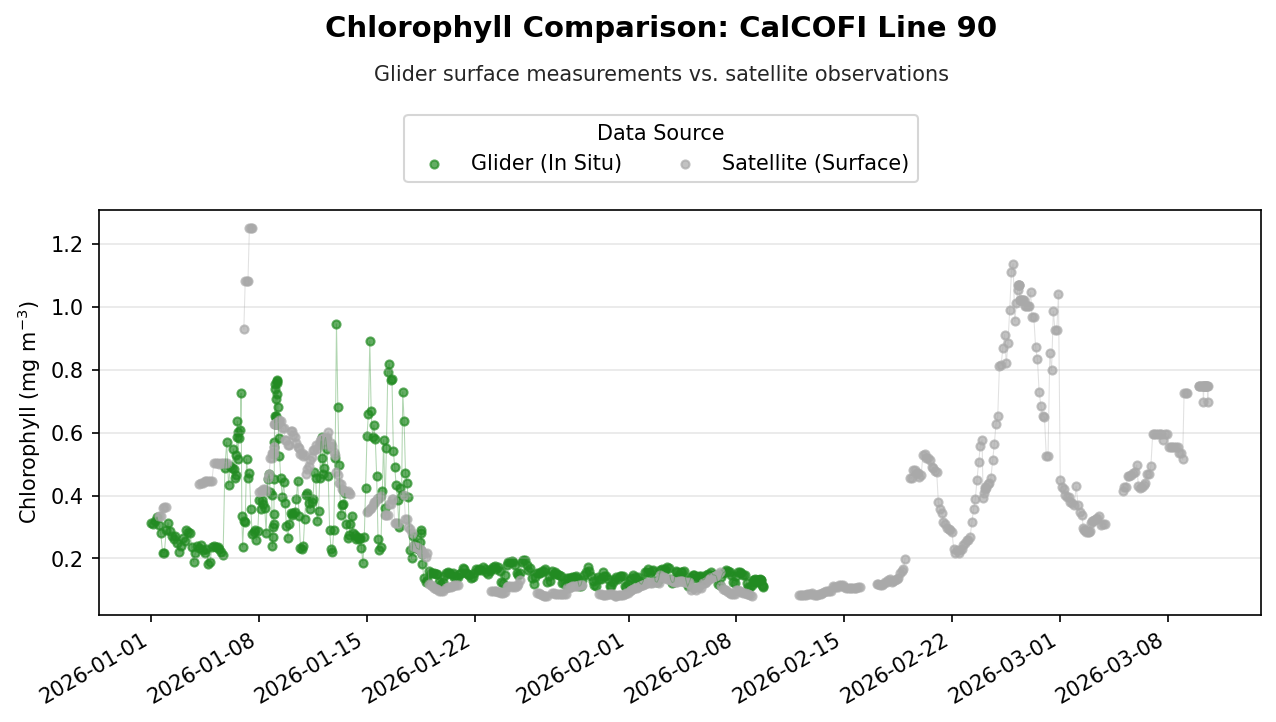

In [18]:
plot_comparison(
    df=glider_surface,
    glider_col="chlorophyll (mg m-3)",
    satellite_col="chl_sat",
    glider_color="forestgreen",
    satellite_label="Satellite (Surface)",
    title="Chlorophyll Comparison",
    ylabel="Chlorophyll (mg m$^{-3}$)",
    titletext="CalCOFI Line 90",
)

### Sea Surface Temperature

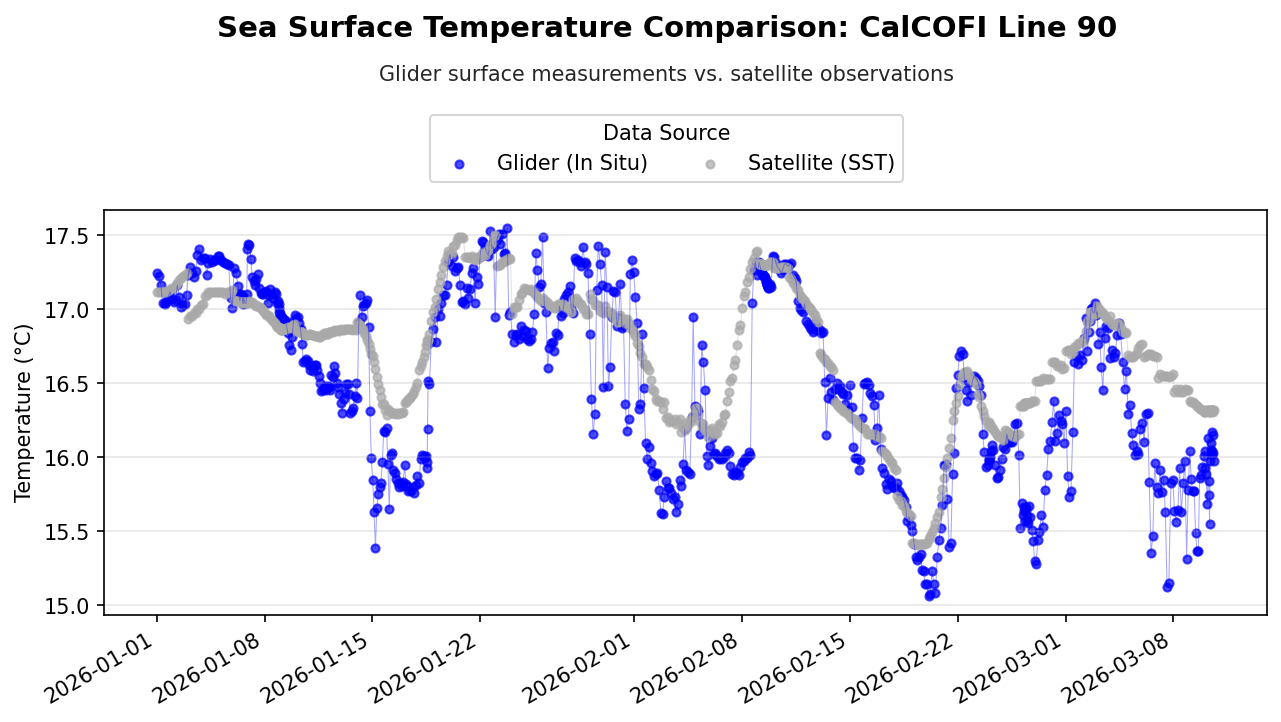

In [19]:
plot_comparison(
    df=glider_surface,
    glider_col="temperature (degree_C)",
    satellite_col="sst_sat",
    glider_color="blue",
    satellite_label="Satellite (SST)",
    title="Sea Surface Temperature Comparison",
    ylabel="Temperature (°C)",
    titletext="CalCOFI Line 90",
)

### Sea Surface Salinity

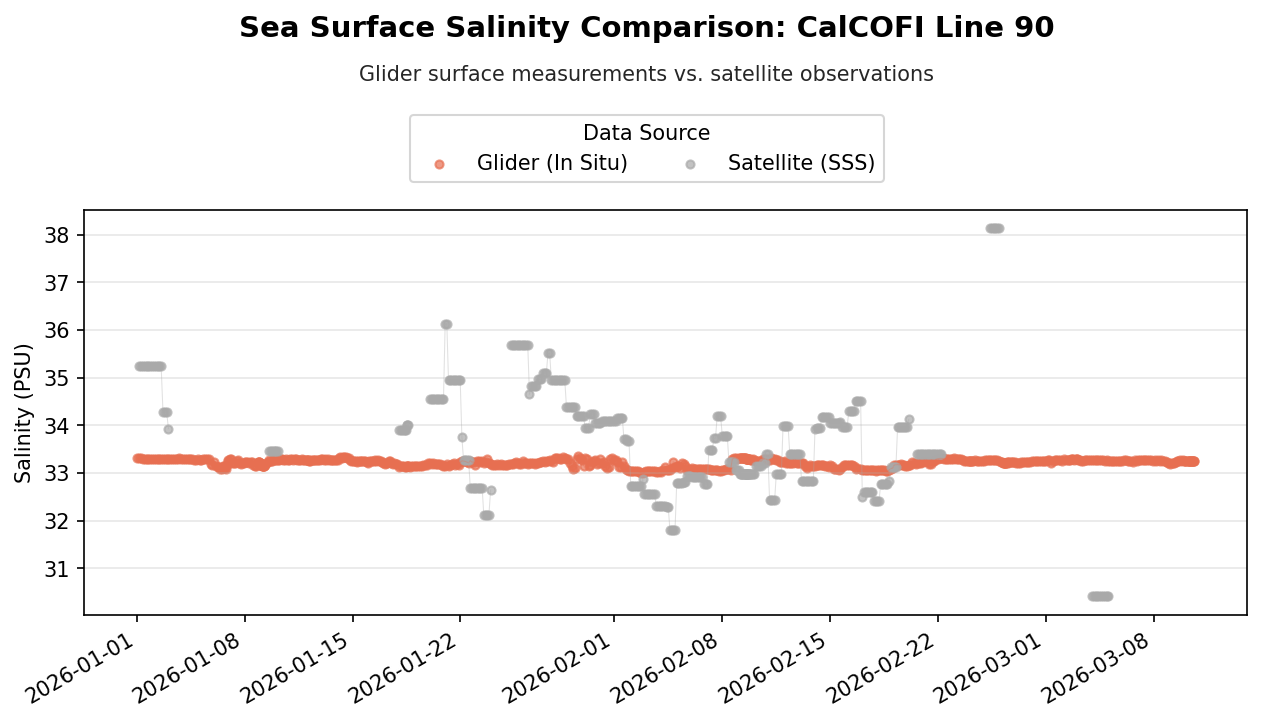

In [20]:
plot_comparison(
    df=glider_surface,
    glider_col="salinity (1)",
    satellite_col="salinity_sat",
    glider_color="#E76F51",
    satellite_label="Satellite (SSS)",
    title="Sea Surface Salinity Comparison",
    ylabel="Salinity (PSU)",
    titletext="CalCOFI Line 90",
)

## Summary

In this tutorial, we:

1. Retrieved in situ glider observations from an ERDDAP server.
2. Selected glider observations at 10 m depth for comparison with surface satellite products.
3. Retrieved satellite chlorophyll-a, sea surface temperature, and sea surface salinity datasets.
4. Restricted the satellite datasets to the glider's spatial and temporal extent.
5. Matched satellite observations to individual glider locations and dates.
6. Combined the satellite and glider measurements into a single DataFrame.
7. Visualized the resulting time-series comparisons.

This workflow can be adapted to other glider deployments or satellite products by changing the ERDDAP dataset IDs, variables, time period, and spatial matching window.